In [23]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneGroupOut,TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,FunctionTransformer,PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
      f1_score,fbeta_score, recall_score, precision_score,
      roc_auc_score, average_precision_score,roc_curve, auc,precision_recall_curve,
      brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
  )
#from sklearn.metrics import fbeta_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show, set_visualize_provider
from interpret.provider import InlineProvider
from pathlib import Path
from datetime import datetime
from scipy.ndimage import gaussian_filter1d
import matplotlib.cm as cm
import matplotlib.dates as mdates




In [24]:
PLOT_DIR = Path("plots") / datetime.now().strftime("%Y%m%d")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name, dpi=150):
      path = PLOT_DIR / f"{name}.png"
      fig.savefig(path, dpi=dpi, bbox_inches='tight')
      print(f"Saved: {path}")

In [25]:
data=pd.read_csv("aurora_dataset_clean.csv")

In [26]:
day_of_year = pd.to_datetime(data["date"]).dt.dayofyear
declination = np.radians(23.45 * np.sin(np.radians(360/365 * (day_of_year - 81))))
lat_rad = np.radians(data['latitude'])

  # Max elevation = solar noon elevation
data['solar_noon_elev_max'] = np.degrees(
    np.arcsin(
        np.sin(lat_rad) * np.sin(declination) +
        np.cos(lat_rad) * np.cos(declination)
    )
)
polar_winter = data["solar_noon_elev_max"] <= 6
dark_enough = ((data["sun_elevation_localtime"] <= 6) | (data["sun_elevation_utc"] <= 6))


In [27]:
features1 = ["mlat","mlon","mlt","kp","bz_gsm","sigma_bz_gsm","solar_wind_speed","ap","Ap"]
features2 = ["cloud_cover","visibility","moon_phase","moon_darkness","sun_elevation_utc","sun_elevation_localtime"]
features1primary0 = ["mlat","mlon","kp","bz_gsm","solar_wind_speed"]
features1primary = ["mlat","mlon","kp","bz_gsm","solar_wind_speed","oval_dist"]
features2primary = ["cloud_cover","moon_darkness","sun_elevation_utc"]
features2primary2 = ["cloud_cover","moon_darkness","mlt"]
features2low = ["mlat","mlon","kp","bz_gsm","solar_wind_speed","oval_dist","cloud_cover","moon_darkness","sun_elevation_utc"]
features2low1 = ["mlat","mlon","kp","bz_gsm","solar_wind_speed","mlt","cloud_cover","moon_darkness"]
features1primary2 = ["mlat","mlon","ap","bz_gsm","solar_wind_speed"]
features1primary3 = ["mlat","mlon","Ap","bz_gsm","solar_wind_speed"]
target = "see_aurora"


In [28]:
clean_columns=data.columns[~data.isna().any()].tolist()

In [29]:
dataclean=data.dropna(subset=features1primary0,how='any',inplace=False)

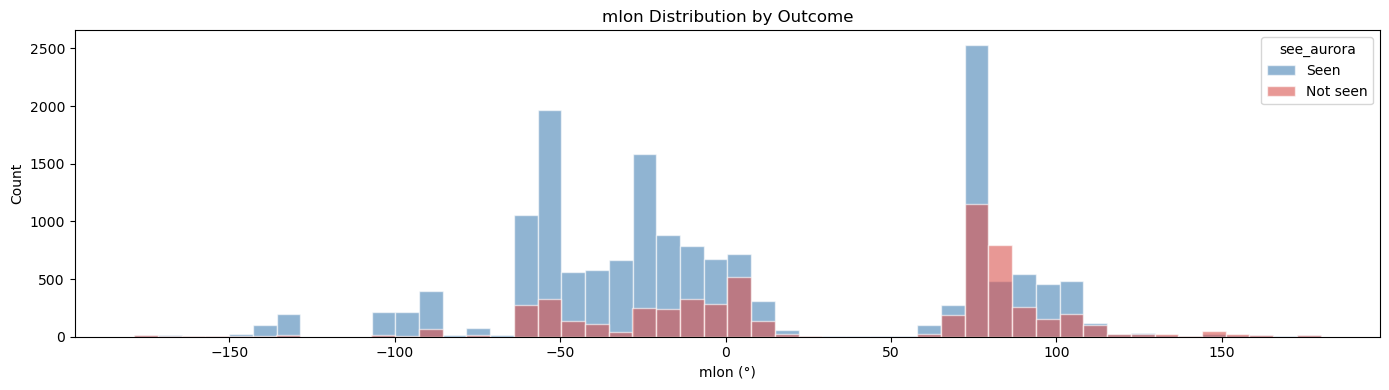

In [30]:
fig, axes = plt.subplots(1, 1, figsize=(14, 4))

# mlat by see_aurora
for seen, color, label in [(True, 'steelblue', 'Seen'), (False, '#d9534f',
'Not seen')]:
    dataclean[dataclean['see_aurora'] == seen]['mlon'].plot(
        kind='hist', bins=50, ax=axes, alpha=0.6,
        color=color, edgecolor='white', label=label
    )
axes.set_title("mlon Distribution by Outcome")
axes.set_xlabel("mlon (°)")
axes.set_ylabel("Count")
axes.legend(title="see_aurora")

plt.tight_layout()
plt.show()

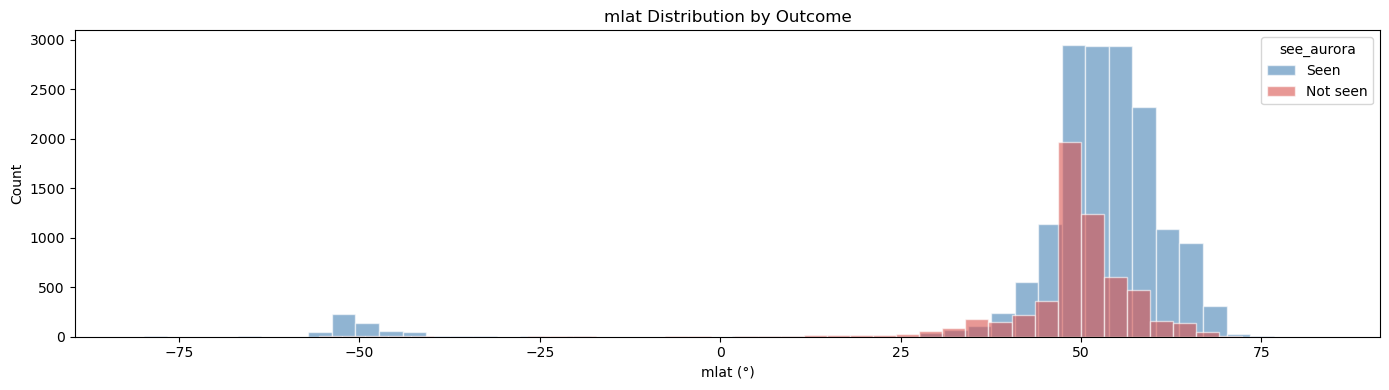

In [31]:
fig, axes = plt.subplots(1, 1, figsize=(14, 4))

# Distribution of mlat
# dataclean['mlat'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue',
# edgecolor='white')
# axes[0].set_title("mlat Distribution (all observations)")
# axes[0].set_xlabel("mlat (°)")
# axes[0].set_ylabel("Count")

# mlat by see_aurora
for seen, color, label in [(True, 'steelblue', 'Seen'), (False, '#d9534f',
'Not seen')]:
    dataclean[dataclean['see_aurora'] == seen]['mlat'].plot(
        kind='hist', bins=50, ax=axes, alpha=0.6,
        color=color, edgecolor='white', label=label
    )
axes.set_title("mlat Distribution by Outcome")
axes.set_xlabel("mlat (°)")
axes.set_ylabel("Count")
axes.legend(title="see_aurora")

plt.tight_layout()
plt.show()


# print(dataclean.groupby('see_aurora')['mlat'].describe().round(2))
# print("\nmlat band counts:")
# bins = [0, 45, 55, 90]
# labels = ['30-45', '45-55', '55-90']
# dataclean['mlat_band'] = pd.cut(dataclean['mlat'].abs(), bins=bins,
# labels=labels)
# print(dataclean.groupby(['mlat_band',
# 'see_aurora']).size().unstack(fill_value=0))


/tmp/ipykernel_328274/1785729014.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  format='ISO8601').dt.to_period('M')


Saved: plots/20260711/monthly_pct_seen.png


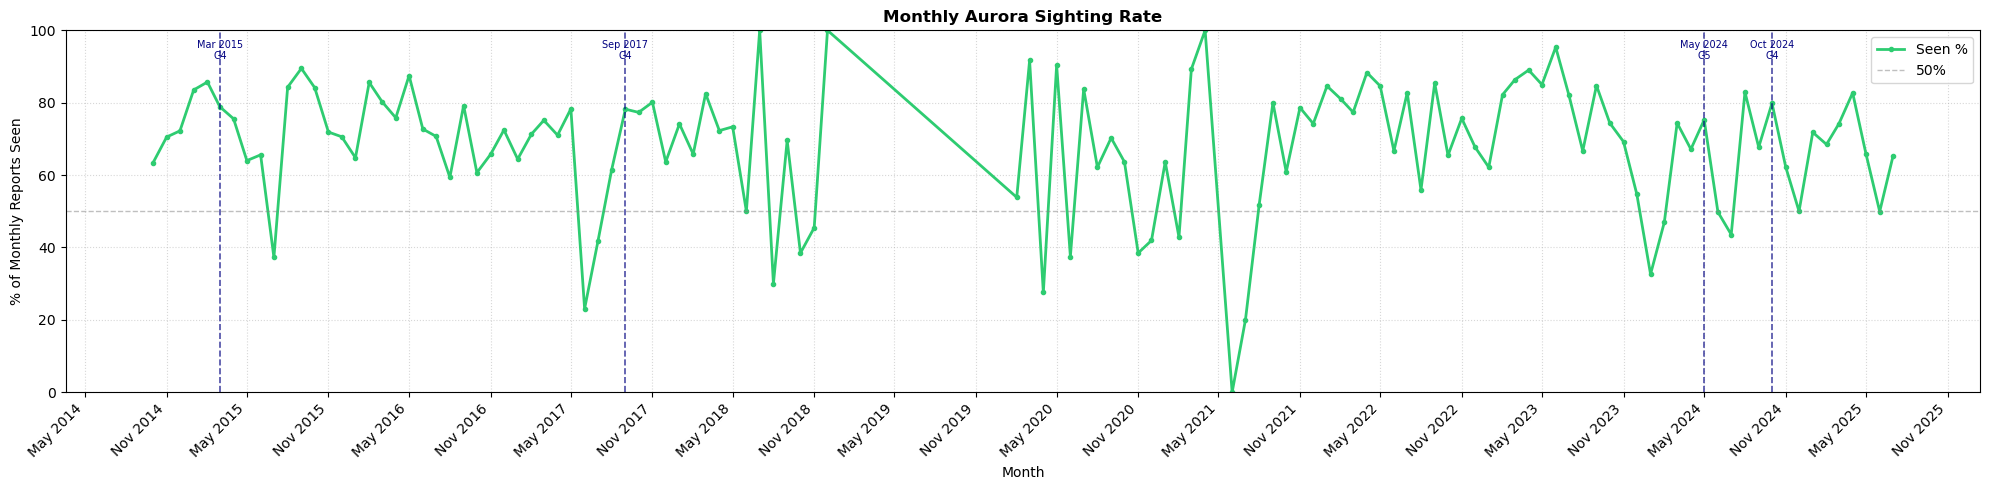

In [32]:


fig, ax = plt.subplots(figsize=(20, 5))

dataclean['month'] = pd.to_datetime(dataclean['utc_dt'],
format='ISO8601').dt.to_period('M')
monthly = dataclean.groupby(['month',
'see_aurora']).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()
total    = monthly[True] + monthly[False]
pct_seen = monthly[True] / total * 100

ax.plot(monthly.index, pct_seen, color='#2ecc71', lw=2, marker='o',
markersize=3, label='Seen %')
ax.axhline(50, color='gray', lw=1, linestyle='--', alpha=0.5, label='50%')

ax.set_ylabel('% of Monthly Reports Seen')
ax.set_xlabel('Month')
ax.set_title('Monthly Aurora Sighting Rate', fontweight='bold')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')

storms = {
'Mar 2015\nG4': '2015-03-01',
'Sep 2017\nG4': '2017-09-01',
'May 2024\nG5': '2024-05-01',
'Oct 2024\nG4': '2024-10-01',
}
for label, date in storms.items():
        ax.axvline(pd.Timestamp(date), color='navy', lw=1.2, linestyle='--',
        alpha=0.7)
        ax.text(pd.Timestamp(date), 92, label, fontsize=7, color='navy',
        ha='center')

plt.tight_layout()
save_fig(fig, "monthly_pct_seen")
plt.show()







Saved: plots/20260711/kp_dist_seen_vs_not_seen.png


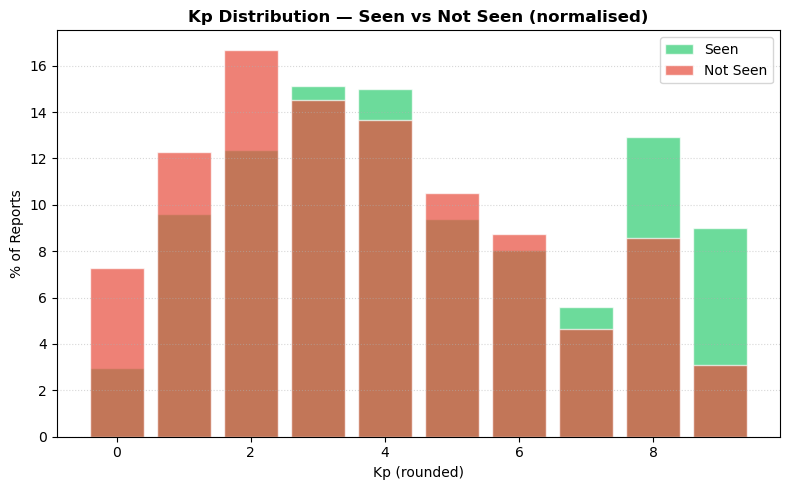

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))

dataclean['kp_round'] = dataclean['kp'].round()

pos = dataclean[dataclean['see_aurora'] == True].groupby('kp_round').size()
neg = dataclean[dataclean['see_aurora'] == False].groupby('kp_round').size()

# Normalise to percentage so scale is comparable
pos_pct = pos / pos.sum() * 100
neg_pct = neg / neg.sum() * 100

ax.bar(pos_pct.index, pos_pct.values, color='#2ecc71', edgecolor='white',
        alpha=0.7, label='Seen')
ax.bar(neg_pct.index, neg_pct.values, color='#e74c3c', edgecolor='white',
        alpha=0.7, label='Not Seen')

ax.set_xlabel('Kp (rounded)') 
ax.set_ylabel('% of Reports')
ax.set_title('Kp Distribution — Seen vs Not Seen (normalised)',
fontweight='bold')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5, axis='y')

plt.tight_layout()
save_fig(fig, "kp_dist_seen_vs_not_seen")
plt.show()


Saved: plots/20260711/kp_dist_seen_vs_not_seen.png


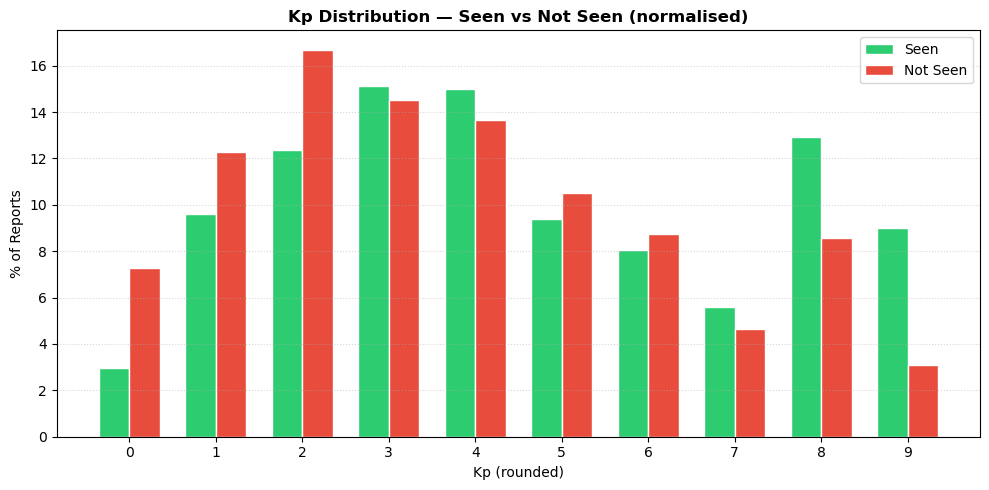

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

dataclean['kp_round'] = dataclean['kp'].round()

pos_pct = dataclean[dataclean['see_aurora'] ==
True].groupby('kp_round').size()
neg_pct = dataclean[dataclean['see_aurora'] ==
False].groupby('kp_round').size()
pos_pct = pos_pct / pos_pct.sum() * 100
neg_pct = neg_pct / neg_pct.sum() * 100

width = 0.35 
kp_vals = sorted(set(pos_pct.index) | set(neg_pct.index))
x = np.arange(len(kp_vals))

ax.bar(x - width/2, [pos_pct.get(k, 0) for k in kp_vals], width=width,
        color='#2ecc71', edgecolor='white', label='Seen')
ax.bar(x + width/2, [neg_pct.get(k, 0) for k in kp_vals], width=width,
        color='#e74c3c', edgecolor='white', label='Not Seen')

ax.set_xticks(x)
ax.set_xticklabels([int(k) for k in kp_vals])
ax.set_xlabel('Kp (rounded)')
ax.set_ylabel('% of Reports')
ax.set_title('Kp Distribution — Seen vs Not Seen (normalised)',
fontweight='bold')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5, axis='y')

plt.tight_layout()
save_fig(fig, "kp_dist_seen_vs_not_seen")
plt.show()


Saved: plots/20260711/kp_dist_seen_vs_not_seen.png


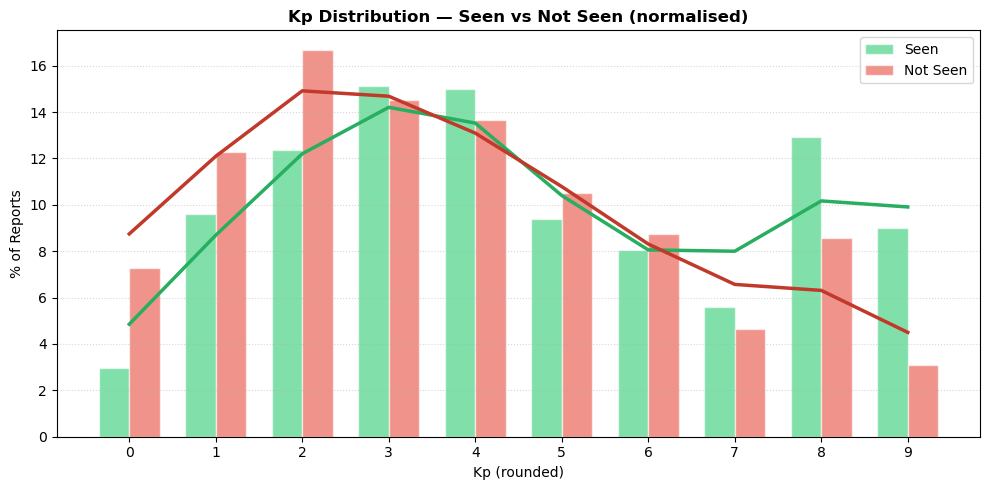

In [35]:

fig, ax = plt.subplots(figsize=(10, 5))

dataclean['kp_round'] = dataclean['kp'].round()

pos_pct = dataclean[dataclean['see_aurora'] ==
True].groupby('kp_round').size()
neg_pct = dataclean[dataclean['see_aurora'] ==
False].groupby('kp_round').size()
pos_pct = pos_pct / pos_pct.sum() * 100
neg_pct = neg_pct / neg_pct.sum() * 100

width   = 0.35
kp_vals = sorted(set(pos_pct.index) | set(neg_pct.index))
x       = np.arange(len(kp_vals))

pos_vals = np.array([pos_pct.get(k, 0) for k in kp_vals])
neg_vals = np.array([neg_pct.get(k, 0) for k in kp_vals])

ax.bar(x - width/2, pos_vals, width=width, color='#2ecc71',
edgecolor='white', alpha=0.6, label='Seen')
ax.bar(x + width/2, neg_vals, width=width, color='#e74c3c',
edgecolor='white', alpha=0.6, label='Not Seen')

# Smooth lines
ax.plot(x, gaussian_filter1d(pos_vals, sigma=0.8), color='#27ae60', lw=2.5)
ax.plot(x, gaussian_filter1d(neg_vals, sigma=0.8), color='#c0392b', lw=2.5)

ax.set_xticks(x)
ax.set_xticklabels([int(k) for k in kp_vals])
ax.set_xlabel('Kp (rounded)')
ax.set_ylabel('% of Reports')
ax.set_title('Kp Distribution — Seen vs Not Seen (normalised)',
fontweight='bold')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5, axis='y')

plt.tight_layout()
save_fig(fig, "kp_dist_seen_vs_not_seen")
plt.show()


In [37]:
dataclean['mlat_band']= pd.cut(dataclean["mlat"].abs(),bins=[0,48,63,90],labels=["00-48","48-63","63-90"])

Saved: plots/20260711/kp_dist_by_mlat_band.png


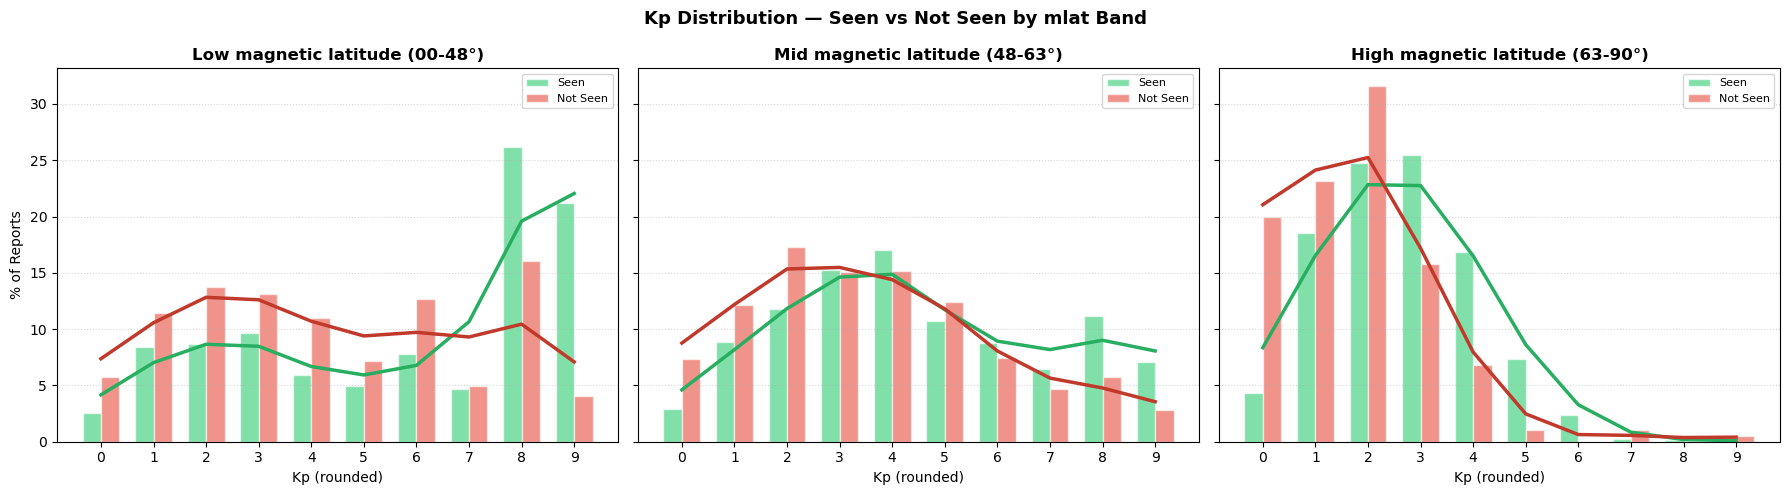

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

bands  = ['00-48', '48-63', '63-90']
titles = ['Low magnetic latitude (00-48°)', 'Mid magnetic latitude (48-63°)', 'High magnetic latitude (63-90°)']

for ax, band, title in zip(axes, bands, titles):
    mask = dataclean['mlat_band'] == band
    sub  = dataclean[mask].copy()
    sub['kp_round'] = sub['kp'].round()

    pos_pct = sub[sub['see_aurora'] == True].groupby('kp_round').size()
    neg_pct = sub[sub['see_aurora'] == False].groupby('kp_round').size()
    pos_pct = pos_pct / pos_pct.sum() * 100
    neg_pct = neg_pct / neg_pct.sum() * 100

    kp_vals  = sorted(set(pos_pct.index) | set(neg_pct.index))
    x        = np.arange(len(kp_vals))
    pos_vals = np.array([pos_pct.get(k, 0) for k in kp_vals])
    neg_vals = np.array([neg_pct.get(k, 0) for k in kp_vals])
    width    = 0.35

    ax.bar(x - width/2, pos_vals, width=width, color='#2ecc71',
edgecolor='white', alpha=0.6, label='Seen')
    ax.bar(x + width/2, neg_vals, width=width, color='#e74c3c',
edgecolor='white', alpha=0.6, label='Not Seen')
    ax.plot(x, gaussian_filter1d(pos_vals, sigma=0.8), color='#27ae60',
lw=2.5)
    ax.plot(x, gaussian_filter1d(neg_vals, sigma=0.8), color='#c0392b',
lw=2.5)

    ax.set_xticks(x)
    ax.set_xticklabels([int(k) for k in kp_vals])
    ax.set_xlabel('Kp (rounded)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5, axis='y')

axes[0].set_ylabel('% of Reports')
plt.suptitle('Kp Distribution — Seen vs Not Seen by mlat Band', fontsize=13,
fontweight='bold')
plt.tight_layout()
save_fig(fig, "kp_dist_by_mlat_band")
plt.show()
